In [1]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt

RESULTS_PATH = "data/experiments/emb_single_patching/vitbase_neutrality/embedding_patching_results.pt"  # <-- change
res = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

print("Top keys:", list(res.keys()))
print("Original keys:", list(res["original"].keys()))
print("Corrupted keys:", list(res["corrupted"].keys()))
print("Patched count:", len(res["patched"]))

emotion_map = res.get("emotion_map", {})
patch_keys = sorted(res["patched"].keys(), key=lambda s: int(s.split("_")[1]))

def _to_np(x):
    if x is None: 
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.array(x)

orig_final = _to_np(res["original"]["final_probs"])[0] 
corr_final = _to_np(res["corrupted"]["final_probs"])[0]
C = orig_final.shape[0]
print("C:", C)

def pretty_label(i):
    if isinstance(emotion_map, dict) and len(emotion_map)>0:
        return str(emotion_map.get(int(i), i))
    return str(i)


Top keys: ['original', 'corrupted', 'patched', 'emotion_map']
Original keys: ['metadata', 'layer_probs', 'final_probs']
Corrupted keys: ['metadata', 'layer_probs', 'final_probs']
Patched count: 196
C: 6


In [ ]:
TRUE_C = int(orig_final.argmax())
print("Using TRUE_C:", TRUE_C, pretty_label(TRUE_C))

def safe_probs(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0)
    return p / p.sum()

def kl(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js(p, q):
    p = safe_probs(p); q = safe_probs(q)
    m = 0.5*(p+q)
    return 0.5*kl(p,m) + 0.5*kl(q,m)

def l1(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(np.abs(p-q)))

def top2(p):
    idx = np.argsort(p)[::-1]
    return int(idx[0]), float(p[idx[0]]), int(idx[1]), float(p[idx[1]])


Using TRUE_C: 1 happiness


In [ ]:
layer_keys = sorted(res["original"]["layer_probs"].keys(), key=lambda x: int(x.split("_")[1]))
layer_ids = [int(k.split("_")[1]) for k in layer_keys]
L = len(layer_keys)
P = len(patch_keys)

print("Layers in probes:", layer_ids[:5], "... total:", L)
print("Patches:", P)

orig_layer_probs = {k: _to_np(res["original"]["layer_probs"][k])[0] for k in layer_keys}
orig_layer_pc = np.array([orig_layer_probs[k][TRUE_C] for k in layer_keys], dtype=np.float32)

orig_pc_final = float(orig_final[TRUE_C])

final_p_correct = np.zeros((P,), dtype=np.float32)
final_delta_correct = np.zeros((P,), dtype=np.float32)
final_js_to_orig = np.zeros((P,), dtype=np.float32)
final_kl_to_orig = np.zeros((P,), dtype=np.float32)
final_l1_to_orig = np.zeros((P,), dtype=np.float32)
final_pred = np.zeros((P,), dtype=np.int32)

layer_delta_correct = np.zeros((P, L), dtype=np.float32)

for pi, pk in enumerate(patch_keys):
    patched = res["patched"][pk]

    p_final = _to_np(patched["final_probs"])[0]
    final_p_correct[pi] = float(p_final[TRUE_C])
    final_delta_correct[pi] = float(p_final[TRUE_C] - orig_pc_final)
    final_js_to_orig[pi] = js(p_final, orig_final)
    final_kl_to_orig[pi] = kl(p_final, orig_final)
    final_l1_to_orig[pi] = l1(p_final, orig_final)
    final_pred[pi] = int(p_final.argmax())

    for lj, lk in enumerate(layer_keys):
        p_layer = _to_np(patched["layer_probs"][lk])[0]
        layer_delta_correct[pi, lj] = float(p_layer[TRUE_C] - orig_layer_probs[lk][TRUE_C])

print("layer_delta_correct:", layer_delta_correct.shape)


Layers in probes: [1, 2, 3, 4, 5] ... total: 11
Patches: 196
layer_delta_correct: (196, 11)


In [ ]:
layer_keys = sorted(res["original"]["layer_probs"].keys(), key=lambda x: int(x.split("_")[1]))
layer_ids = [int(k.split("_")[1]) for k in layer_keys]
L = len(layer_keys)
P = len(patch_keys)

print("Layers in probes:", layer_ids[:5], "... total:", L)
print("Patches:", P)

orig_layer_probs = {k: _to_np(res["original"]["layer_probs"][k])[0] for k in layer_keys}
orig_layer_pc = np.array([orig_layer_probs[k][TRUE_C] for k in layer_keys], dtype=np.float32)

orig_pc_final = float(orig_final[TRUE_C])

final_p_correct = np.zeros((P,), dtype=np.float32)
final_delta_correct = np.zeros((P,), dtype=np.float32)
final_js_to_orig = np.zeros((P,), dtype=np.float32)
final_kl_to_orig = np.zeros((P,), dtype=np.float32)
final_l1_to_orig = np.zeros((P,), dtype=np.float32)
final_pred = np.zeros((P,), dtype=np.int32)

layer_delta_correct = np.zeros((P, L), dtype=np.float32)

for pi, pk in enumerate(patch_keys):
    patched = res["patched"][pk]

    p_final = _to_np(patched["final_probs"])[0]
    final_p_correct[pi] = float(p_final[TRUE_C])
    final_delta_correct[pi] = float(p_final[TRUE_C] - orig_pc_final)
    final_js_to_orig[pi] = js(p_final, orig_final)
    final_kl_to_orig[pi] = kl(p_final, orig_final)
    final_l1_to_orig[pi] = l1(p_final, orig_final)
    final_pred[pi] = int(p_final.argmax())

    for lj, lk in enumerate(layer_keys):
        p_layer = _to_np(patched["layer_probs"][lk])[0]
        layer_delta_correct[pi, lj] = float(p_layer[TRUE_C] - orig_layer_probs[lk][TRUE_C])

print("layer_delta_correct:", layer_delta_correct.shape)


Layers in probes: [1, 2, 3, 4, 5] ... total: 11
Patches: 196
layer_delta_correct: (196, 11)


In [ ]:
orig_pred = int(orig_final.argmax())
corr_pred = int(corr_final.argmax())

order = np.argsort(final_delta_correct)
print("orig_pred:", orig_pred, pretty_label(orig_pred))
print("corr_pred:", corr_pred, pretty_label(corr_pred))

print("\nTop 20 most damaging patches (most negative Δp(correct)):")
for idx in order[:20]:
    pk = patch_keys[idx]
    p_final = _to_np(res["patched"][pk]["final_probs"])[0]
    a0, p0, a1, p1 = top2(p_final)
    print(f"{pk:<10} token={res['patched'][pk]['token_index']:<3} "
          f"Δp={final_delta_correct[idx]:+.6f} p_correct={final_p_correct[idx]:.6f} "
          f"pred={pretty_label(a0)}(p={p0:.4f}) runnerup={pretty_label(a1)}(p={p1:.4f}) "
          f"JS={final_js_to_orig[idx]:.4f} flip={(a0!=orig_pred)}")


orig_pred: 1 happiness
corr_pred: 2 sadness

Top 20 most damaging patches (most negative Δp(correct)):
patch_117  token=118 Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_90   token=91  Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_120  token=121 Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_89   token=90  Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_91   token=92  Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_148  token=149 Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_118  token=119 Δp=-0.000000 p_correct=1.000000 pred=happiness(p=1.0000) runnerup=disgust(p=0.0000) JS=0.0000 flip=False
patch_121  toke

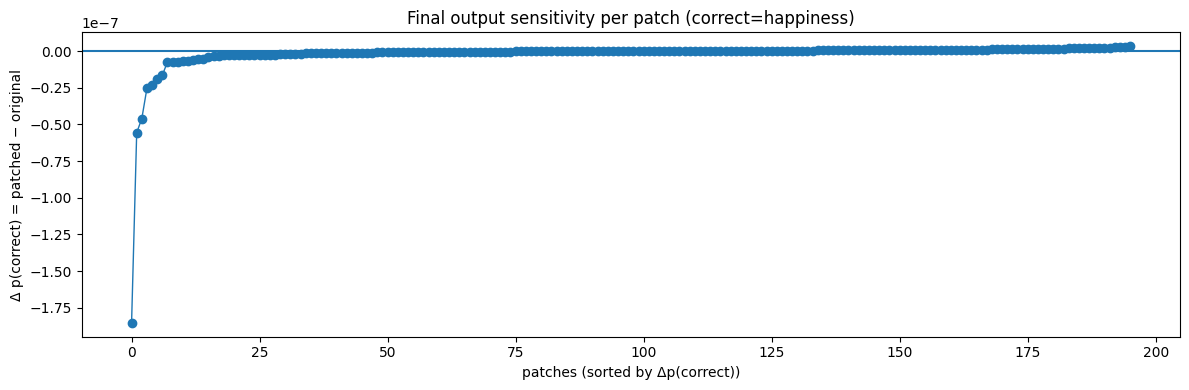

Most damaging: patch_117 Δp= -1.853386777384003e-07
Least damaging: patch_132 Δp= 3.331269482487187e-09


In [7]:
plt.figure(figsize=(12,4))
plt.plot(final_delta_correct[order], marker="o", linewidth=1)
plt.axhline(0.0)
plt.xlabel("patches (sorted by Δp(correct))")
plt.ylabel("Δ p(correct) = patched − original")
plt.title(f"Final output sensitivity per patch (correct={pretty_label(TRUE_C)})")
plt.tight_layout()
plt.show()

print("Most damaging:", patch_keys[order[0]], "Δp=", float(final_delta_correct[order[0]]))
print("Least damaging:", patch_keys[order[-1]], "Δp=", float(final_delta_correct[order[-1]]))


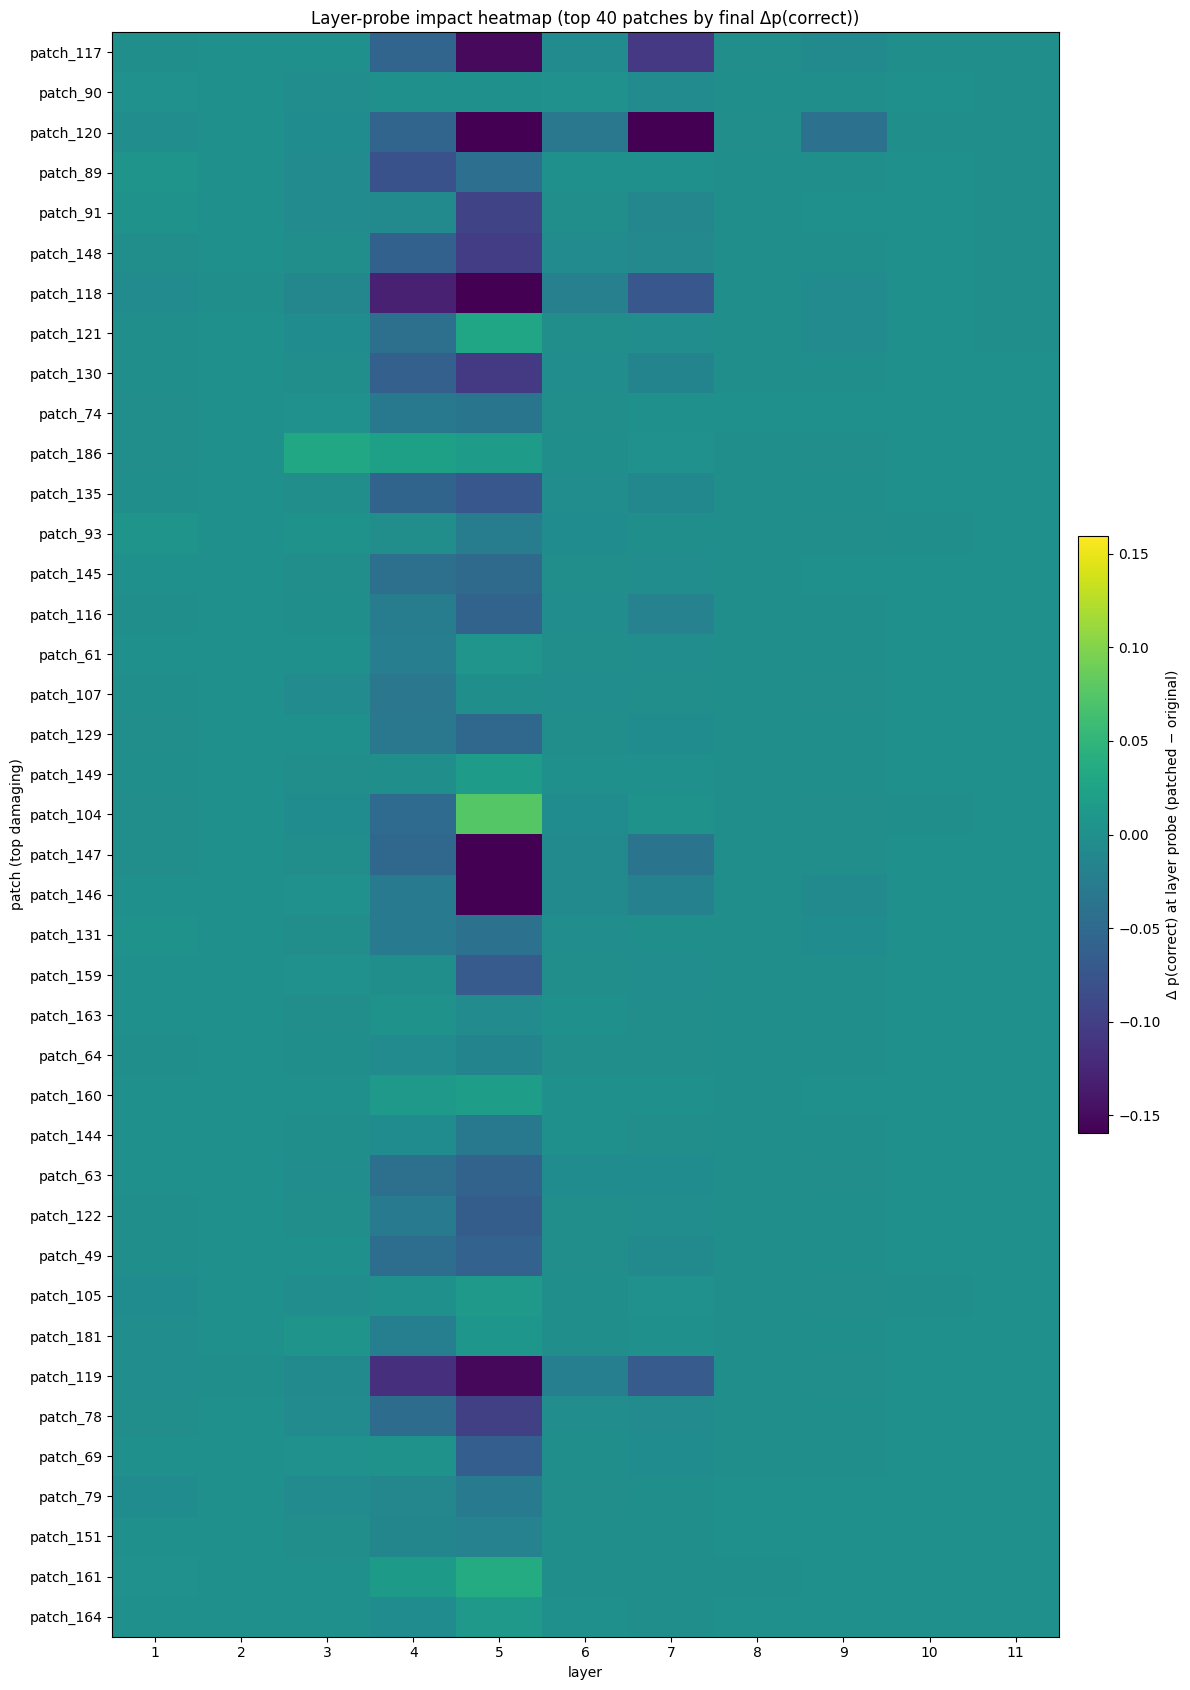

In [ ]:
TOP_K = 40
top_idx = order[:min(TOP_K, P)]
M = layer_delta_correct[top_idx, :]
patch_top = [patch_keys[i] for i in top_idx]

finite = M[np.isfinite(M)]
v = float(np.quantile(np.abs(finite), 0.99)) if finite.size else 1e-6
v = max(v, 1e-6)

plt.figure(figsize=(12, 0.35*len(top_idx) + 3))
im = plt.imshow(M, aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
plt.colorbar(im, fraction=0.03, pad=0.02, label="Δ p(correct) at layer probe (patched − original)")
plt.yticks(np.arange(len(top_idx)), patch_top)
plt.xticks(np.arange(L), layer_ids)
plt.xlabel("layer")
plt.ylabel("patch (top damaging)")
plt.title(f"Layer-probe impact heatmap (top {len(top_idx)} patches by final Δp(correct))")
plt.tight_layout()
plt.show()


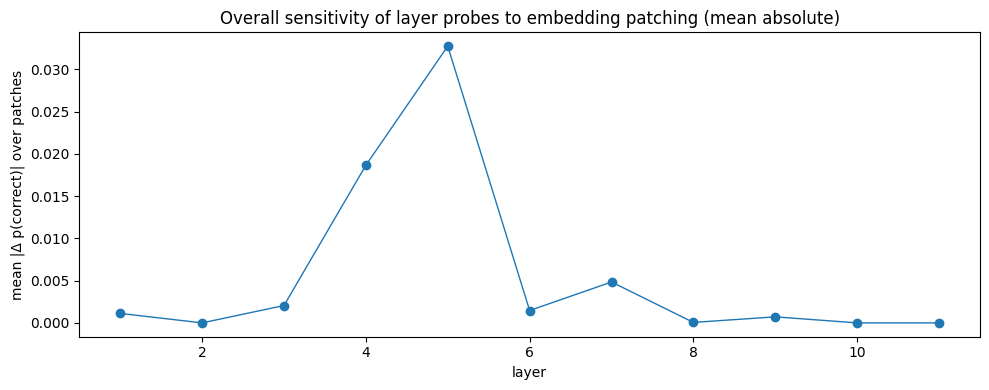

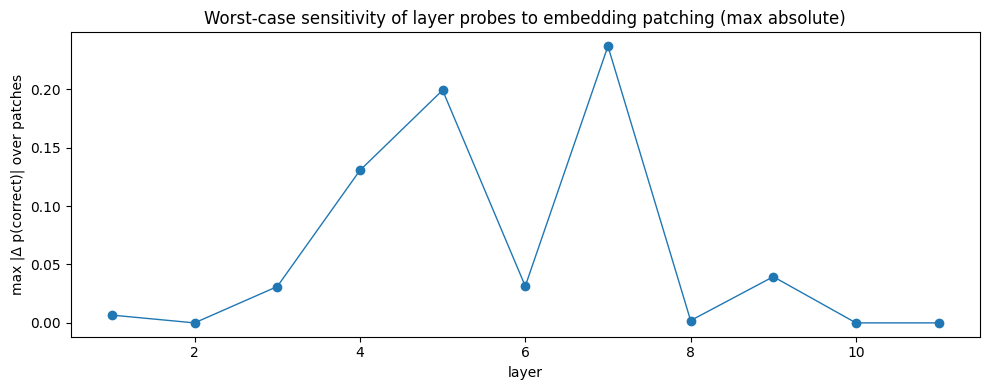

In [ ]:
mean_abs = np.mean(np.abs(layer_delta_correct), axis=0)  # [L]
max_abs = np.max(np.abs(layer_delta_correct), axis=0)

plt.figure(figsize=(10,4))
plt.plot(layer_ids, mean_abs, marker="o", linewidth=1)
plt.xlabel("layer")
plt.ylabel("mean |Δ p(correct)| over patches")
plt.title("Overall sensitivity of layer probes to embedding patching (mean absolute)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(layer_ids, max_abs, marker="o", linewidth=1)
plt.xlabel("layer")
plt.ylabel("max |Δ p(correct)| over patches")
plt.title("Worst-case sensitivity of layer probes to embedding patching (max absolute)")
plt.tight_layout()
plt.show()


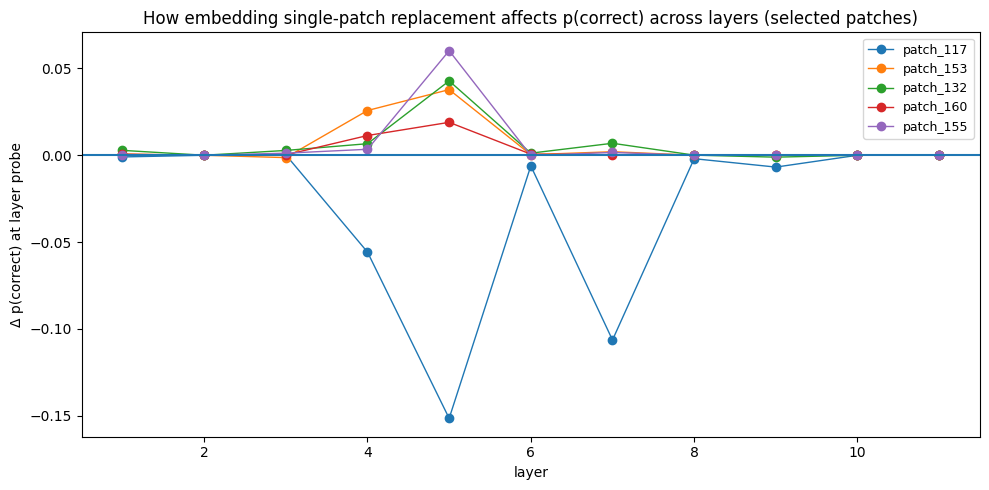

In [ ]:
sel = [order[0], order[len(order)//2], order[-1]]
if P > 6:
    sel += list(np.random.choice(order[1:-1], size=2, replace=False))

plt.figure(figsize=(10,5))
for idx in sel:
    plt.plot(layer_ids, layer_delta_correct[idx], marker="o", linewidth=1, label=patch_keys[idx])
plt.axhline(0.0)
plt.xlabel("layer")
plt.ylabel("Δ p(correct) at layer probe")
plt.title("How embedding single-patch replacement affects p(correct) across layers (selected patches)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


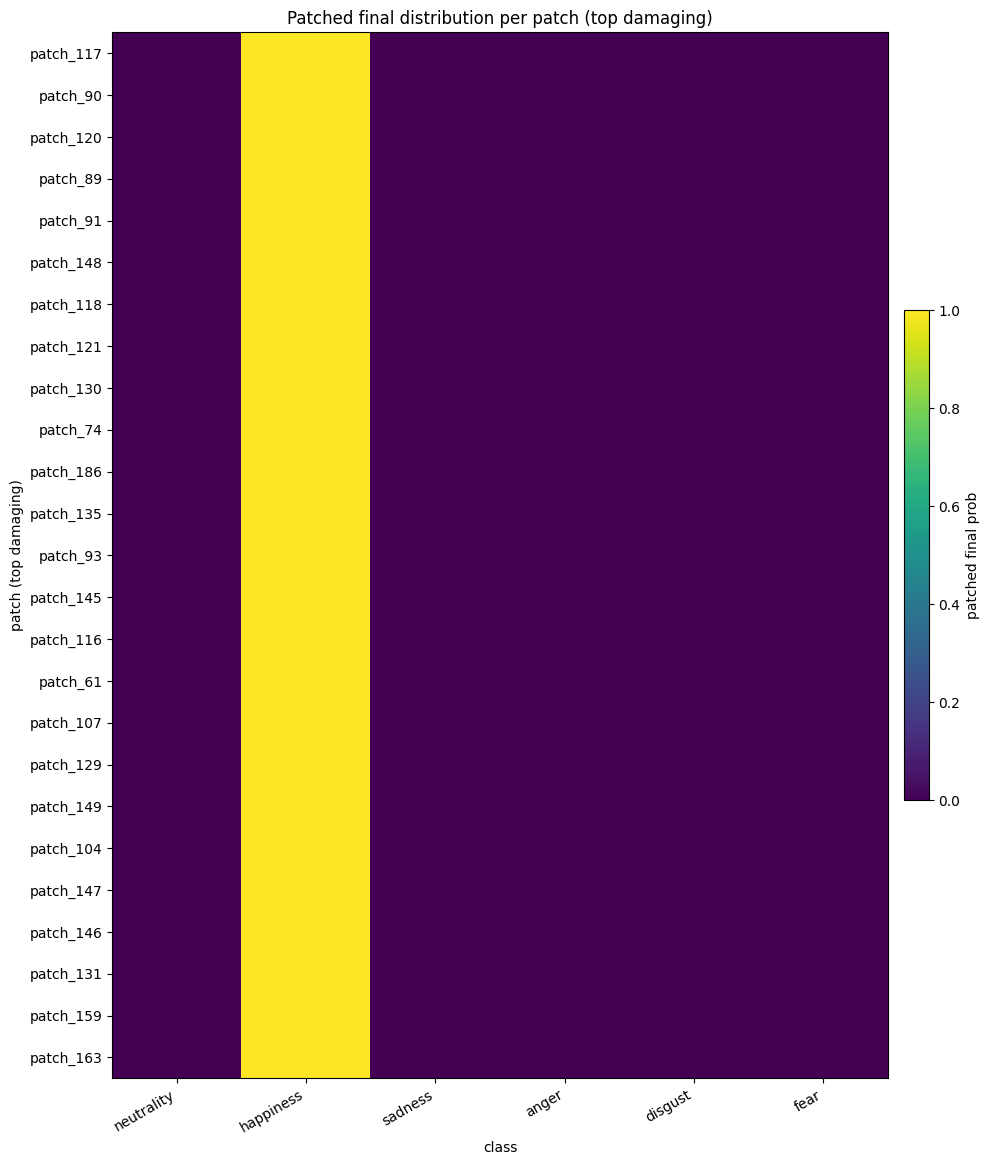

In [12]:
TOP_K = 25
top_idx = order[:min(TOP_K, P)]
patch_top = [patch_keys[i] for i in top_idx]

F = np.zeros((len(top_idx), C), dtype=np.float32)
for r, idx in enumerate(top_idx):
    pk = patch_keys[idx]
    F[r] = _to_np(res["patched"][pk]["final_probs"])[0]

plt.figure(figsize=(10, 0.35*len(top_idx) + 3))
im = plt.imshow(F, aspect="auto", interpolation="nearest", vmin=0.0, vmax=1.0)
plt.colorbar(im, fraction=0.03, pad=0.02, label="patched final prob")
plt.yticks(np.arange(len(top_idx)), patch_top)
plt.xticks(np.arange(C), [pretty_label(i) for i in range(C)], rotation=30, ha="right")
plt.xlabel("class")
plt.ylabel("patch (top damaging)")
plt.title("Patched final distribution per patch (top damaging)")
plt.tight_layout()
plt.show()


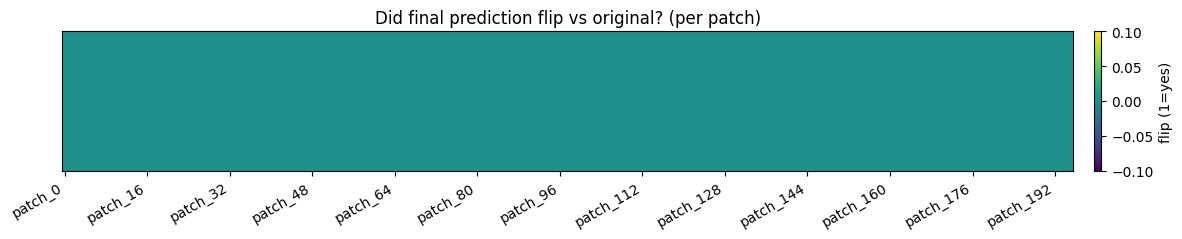

Final prediction distribution across patches:
happiness: 196
Total flips: 0 / 196


In [13]:
pred = final_pred
flip = (pred != orig_pred).astype(np.int32)

plt.figure(figsize=(12,2.5))
im = plt.imshow(flip.reshape(1, -1), aspect="auto", interpolation="nearest")
plt.colorbar(im, fraction=0.03, pad=0.02, label="flip (1=yes)")
plt.yticks([])
plt.xticks(np.arange(0, P, max(1, P//12)), [patch_keys[i] for i in range(0, P, max(1, P//12))], rotation=30, ha="right")
plt.title("Did final prediction flip vs original? (per patch)")
plt.tight_layout()
plt.show()

unique, counts = np.unique(pred, return_counts=True)
print("Final prediction distribution across patches:")
for u,cnt in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f"{pretty_label(u)}: {cnt}")
print("Total flips:", int(flip.sum()), "/", P)
